# VPINS — AIA Challenge: Train v2 (đánh giá trung thực + chọn ổn định)

Bản nâng cấp của `model.ipynb`, áp dụng các phát hiện từ EDA. **Khác biệt cốt lõi:**

- **P1 — GroupKFold theo profile:** dòng trùng 85 đặc trưng (EDA mục 2b) không còn nằm cả ở
  train lẫn validation → OOF `hits@20%` **trung thực** (hết lạc quan). Có cell đo trực tiếp.
- **P2 — Chọn ổn định:** xếp hạng bằng `mean_hits_over_k` (trung bình hits ở K=15..25%) +
  tie-break AUC; **ưu tiên rank-average** (bền cho ranking).
- **P3 — Tuning mượt hơn:** objective = `hits_meanK` (bớt nhiễu so với hits@20% đơn lẻ).
- **P4 — Mất cân bằng:** với bài *ranking* top-K, resampling gần như bất biến → bỏ SMOTE.
- **P5 — FE:** sửa lệch index khi tính MI (`encoded_layout`) + thử `extra_flags`.

> Tất cả gọi hàm trong `src/` (đã nâng cấp opt-in). Output → `*_v2` để **không đè** bản v1.

## 1. Cấu hình, nạp dữ liệu & nhóm profile

In [1]:
import warnings, os, sys, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sys.path.insert(0, os.getcwd())

from src.data import load_data, TARGET, FEATURES, disp, NAME
from src.features import build_features, feature_sets, make_preprocessor, encoded_layout, extra_flags
from src.models import get_models
from src.cv import run_zoo, oof_proba, build_pipeline, profile_groups
from src.tune import tune_model, build_tuned_estimator
from src.ensemble import compare_ensembles, rank_average, to_rank, stack_oof
from src.predict import fit_full, score_test, make_submission, verify_submission
from src.metrics import summarize, topk_hits, lift_at_k, mean_hits_over_k

plt.rcParams["font.sans-serif"] = ["Segoe UI", "Arial", "Tahoma", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
def savefig(n): plt.savefig(FIG / (n + ".png"), dpi=150, bbox_inches="tight")

# ---- Cấu hình. FAST=True để chạy nhanh (kiểm thử); đặt False cho bản nộp cuối. ----
FAST = True
N_REPEATS = 3 if FAST else 5
N_TRIALS  = {"LightGBM": 8, "XGBoost": 8, "CatBoost": 6} if FAST else {"LightGBM": 40, "XGBoost": 40, "CatBoost": 30}
TUNE_OBJ  = "hits_meanK"     # objective mượt cho tuning (P3)
INNER_ES  = False            # dữ liệu ít dương -> inner early-stop dễ dừng sớm; để False
SEED = 42
print("FAST =", FAST, "| N_REPEATS =", N_REPEATS, "| N_TRIALS =", N_TRIALS, "| TUNE_OBJ =", TUNE_OBJ)

FAST = True | N_REPEATS = 3 | N_TRIALS = {'LightGBM': 8, 'XGBoost': 8, 'CatBoost': 6} | TUNE_OBJ = hits_meanK


In [2]:
train, test = load_data()
Xtr, Xte, ENG = build_features(train, test)
y = train[TARGET].astype(int); pos_rate = y.mean()
test_ids = test["ID"].values

# P5: ghép sẵn các flag thử nghiệm; feature selection sẽ quyết định có dùng không
EX_tr, EX_te = extra_flags(Xtr), extra_flags(Xte)
Xtr = pd.concat([Xtr, EX_tr], axis=1); Xte = pd.concat([Xte, EX_te], axis=1)
EXTRA = list(EX_tr.columns)
COLS = feature_sets(ENG)["eng"]          # 85 gốc + đặc trưng tổng hợp
COLS_X = COLS + EXTRA                     # + flag thử nghiệm

# P1: nhóm theo profile (85 đặc trưng gốc) cho GroupKFold
GROUPS = profile_groups(Xtr)
print(f"Train {Xtr.shape} | Test {Xte.shape} | tỉ lệ dương {pos_rate:.4f}")
print(f"Số profile (nhóm): {len(np.unique(GROUPS))} / {len(Xtr)}  -> dùng cho StratifiedGroupKFold")
print(f"COLS eng = {len(COLS)} | + extra_flags {EXTRA} -> COLS_X = {len(COLS_X)}")

Train (5822, 102) | Test (4000, 101) | tỉ lệ dương 0.0598
Số profile (nhóm): 5171 / 5822  -> dùng cho StratifiedGroupKFold
COLS eng = 98 | + extra_flags ['flag_so_hd_oto', 'flag_da_dang_bh'] -> COLS_X = 100


## 2. Rò rỉ CV: Leaky (StratifiedKFold) vs Grouped (StratifiedGroupKFold) — P1

Đo phần "lạc quan" do dòng trùng profile bị chia vào cả train lẫn validation. Mô hình **ghi
nhớ** (cây) chịu ảnh hưởng nhiều hơn mô hình tuyến tính.

              leaky  grouped  lạc quan (Δ)
model                                     
LogReg          178      172             6
RandomForest    170      168             2
LightGBM        162      169            -7


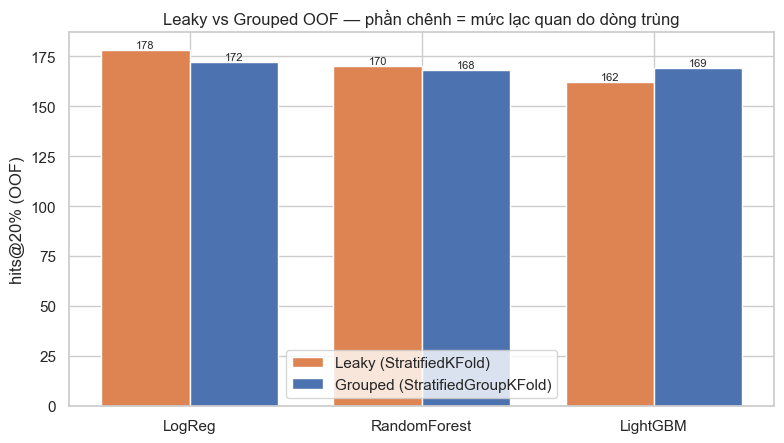

=> Dùng GROUPED cho mọi đánh giá phía dưới. Con số có thể thấp hơn v1 nhưng ĐÁNG TIN.


In [3]:
from sklearn.linear_model import LogisticRegression
cmp_models = {
 "LogReg": {"est": LogisticRegression(max_iter=2000, class_weight="balanced"), "scale": True, "te": True},
 "RandomForest": get_models(pos_rate)["RandomForest"],
 "LightGBM": get_models(pos_rate)["LightGBM"],
}
rows = []
for nm, sp in cmp_models.items():
    o_leak, _ = oof_proba(sp, Xtr, y, COLS, n_repeats=2, seed=SEED)               # leaky
    o_grp,  _ = oof_proba(sp, Xtr, y, COLS, n_repeats=2, seed=SEED, groups=GROUPS) # grouped
    rows.append({"model": nm, "leaky": summarize(y, o_leak)["hits@20%"],
                 "grouped": summarize(y, o_grp)["hits@20%"]})
leak = pd.DataFrame(rows).set_index("model")
leak["lạc quan (Δ)"] = leak["leaky"] - leak["grouped"]
print(leak)

fig, ax = plt.subplots(figsize=(8, 4.6))
xpos = np.arange(len(leak)); w = 0.38
ax.bar(xpos - w/2, leak["leaky"], w, label="Leaky (StratifiedKFold)", color="#dd8452")
ax.bar(xpos + w/2, leak["grouped"], w, label="Grouped (StratifiedGroupKFold)", color="#4c72b0")
ax.set_xticks(xpos); ax.set_xticklabels(leak.index)
ax.set_ylabel("hits@20% (OOF)"); ax.legend()
ax.set_title("Leaky vs Grouped OOF — phần chênh = mức lạc quan do dòng trùng")
for i, (l_, g_) in enumerate(zip(leak["leaky"], leak["grouped"])):
    ax.text(i - w/2, l_, int(l_), ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, g_, int(g_), ha="center", va="bottom", fontsize=8)
plt.tight_layout(); savefig("MV01_leak_check"); plt.show()
print("=> Dùng GROUPED cho mọi đánh giá phía dưới. Con số có thể thấp hơn v1 nhưng ĐÁNG TIN.")

## 3. Model zoo — CV baseline (grouped OOF) — P1

In [4]:
models = get_models(pos_rate)
print("Chạy", len(models), "mô hình (grouped,", N_REPEATS, "x 5-fold)...")
t0 = time.time()
base_res, base_oof = run_zoo(models, Xtr, y, COLS, n_repeats=N_REPEATS, seed=SEED, groups=GROUPS, verbose=False)
print(f"Xong {time.time()-t0:.0f}s")
base_res[["AUC", "AP", "hits@20%", "hits@20%_std", "recall@20%", "lift@20%"]].round(4)

Chạy 10 mô hình (grouped, 3 x 5-fold)...


Xong 230s


,AUC,AP,hits@20%,hits@20%_std,recall@20%,lift@20%
model,,,,,,
LDA,0.7485,0.1654,183,0.9428,0.5259,2.6280
CatBoost,0.7668,0.1678,183,3.8586,0.5259,2.6280
XGBoost,0.7601,0.1587,180,6.1824,0.5172,2.5849
BernoulliNB,0.7303,0.1521,177,0.0000,0.5086,2.5418
LogReg,0.7384,0.1509,174,3.2998,0.5000,2.4987
LightGBM,0.7479,0.1426,168,0.8165,0.4828,2.4125
RandomForest,0.7443,0.1406,164,0.4714,0.4713,2.3551
ExtraTrees,0.7366,0.1354,160,2.3570,0.4598,2.2977
HistGB,0.7347,0.1367,160,2.8674,0.4598,2.2977


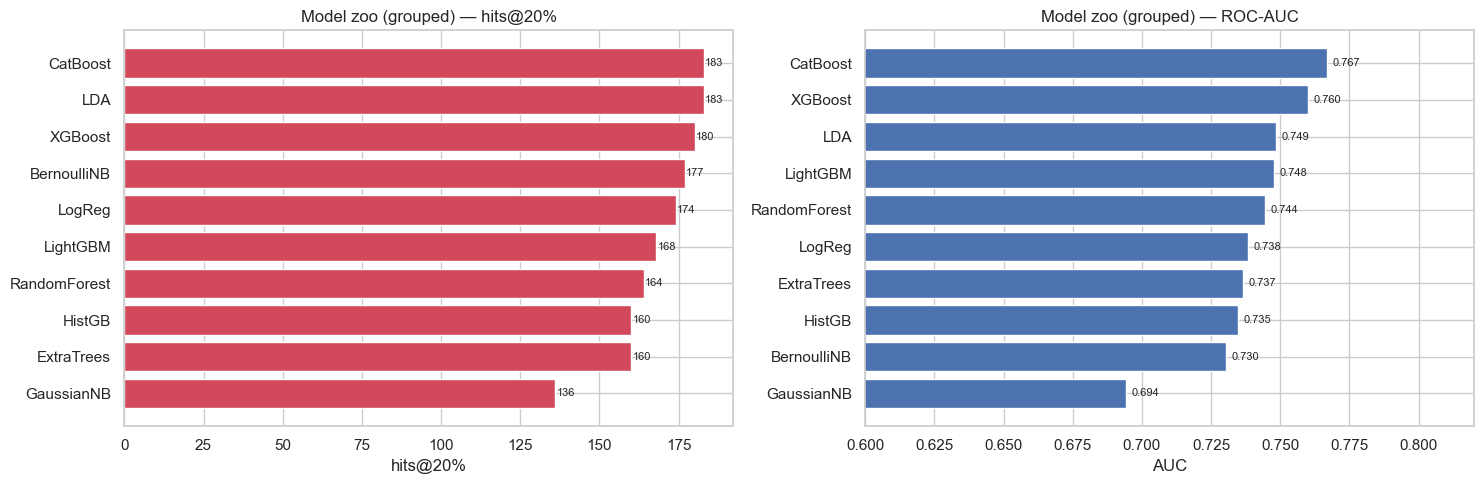

Top 3 (grouped hits@20%): ['LDA', 'CatBoost', 'XGBoost']


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
r = base_res.sort_values("hits@20%")
axes[0].barh(r.index, r["hits@20%"], color="#d1495b")
axes[0].set_title("Model zoo (grouped) — hits@20%"); axes[0].set_xlabel("hits@20%")
for i, v in enumerate(r["hits@20%"]): axes[0].text(v+0.4, i, int(v), va="center", fontsize=8)
r2 = base_res.sort_values("AUC")
axes[1].barh(r2.index, r2["AUC"], color="#4c72b0"); axes[1].set_xlim(0.6, 0.82)
axes[1].set_title("Model zoo (grouped) — ROC-AUC"); axes[1].set_xlabel("AUC")
for i, v in enumerate(r2["AUC"]): axes[1].text(v+0.002, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout(); savefig("MV02_model_zoo"); plt.show()
print("Top 3 (grouped hits@20%):", list(base_res.head(3).index))

## 4. Xử lý mất cân bằng — gần như bất biến với ranking — P4

Với bài toán xếp hạng top-K, thứ tự điểm ít đổi theo cách xử lý mất cân bằng. SMOTE còn rủi
ro tạo điểm nhân tạo trong không gian thưa + nhiều dòng trùng → **không dùng ở đường chính**.

In [6]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from lightgbm import LGBMClassifier
from sklearn.base import clone

spw = (1 - pos_rate) / pos_rate
def lgbm(**kw): return LGBMClassifier(n_estimators=400, learning_rate=0.03, num_leaves=31,
                                      subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                                      n_jobs=-1, verbose=-1, **kw)
def oof_imb(sampler, clf):
    steps = [("pre", make_preprocessor(COLS, scale=False))]
    if sampler is not None: steps.append(("samp", sampler))
    steps.append(("clf", clone(clf)))
    pipe = ImbPipeline(steps)
    oof = np.zeros(len(y))
    for r in range(N_REPEATS):
        cv = StratifiedGroupKFold(5, shuffle=True, random_state=SEED+r)
        oof += cross_val_predict(pipe, Xtr, y, cv=cv, method="predict_proba", n_jobs=1, groups=GROUPS)[:, 1]
    return oof / N_REPEATS

scen = {"Không xử lý": (None, lgbm()), "scale_pos_weight": (None, lgbm(scale_pos_weight=spw)),
        "SMOTE": (SMOTE(random_state=SEED), lgbm()), "Undersample": (RandomUnderSampler(random_state=SEED), lgbm())}
rows = []
for nm, (s, c) in scen.items():
    d = summarize(y, oof_imb(s, c)); d["Cách xử lý"] = nm; rows.append(d)
imb_res = pd.DataFrame(rows).set_index("Cách xử lý").sort_values("hits@20%", ascending=False)
print(imb_res[["AUC", "AP", "hits@20%", "lift@20%"]].round(4))
print("=> Chênh lệch nhỏ -> xếp hạng ~bất biến. Dùng scale_pos_weight/none; KHÔNG dùng SMOTE.")

                     AUC      AP  hits@20%  lift@20%
Cách xử lý                                          
Undersample       0.7604  0.1454       178    2.5562
scale_pos_weight  0.7522  0.1452       168    2.4125
SMOTE             0.7501  0.1510       168    2.4125
Không xử lý       0.7552  0.1436       165    2.3695
=> Chênh lệch nhỏ -> xếp hạng ~bất biến. Dùng scale_pos_weight/none; KHÔNG dùng SMOTE.


## 5. Feature selection ("less is more") + sửa MI — P5

Tính mutual information ĐÚNG (`encoded_layout` khớp thứ tự cột sau ColumnTransformer + đánh
dấu cột rời rạc). So các bộ đặc trưng bằng grouped OOF của mô hình baseline tốt nhất.

In [7]:
from sklearn.feature_selection import mutual_info_classif
ordered, dmask = encoded_layout(COLS_X)
Xenc = make_preprocessor(COLS_X, scale=False).fit_transform(Xtr, y)
mi = pd.Series(mutual_info_classif(Xenc, y, discrete_features=dmask, random_state=SEED),
               index=ordered).sort_values(ascending=False)

best_name = base_res.index[0]; best_spec = models[best_name]
def oof_hits(cols):
    o, _ = oof_proba(best_spec, Xtr, y, cols, n_repeats=N_REPEATS, seed=SEED, groups=GROUPS)
    return summarize(y, o)

cand = {"raw (85)": feature_sets(ENG)["raw"], "eng": COLS, "eng + extra_flags": COLS_X}
for k in [20, 30, 40]: cand[f"top{k} MI"] = mi.head(k).index.tolist()
fs_rows = []
for nm, cs in cand.items():
    d = oof_hits(cs); d["Bộ đặc trưng"] = nm; d["n_cột"] = len(cs); fs_rows.append(d)
fs_res = pd.DataFrame(fs_rows).set_index("Bộ đặc trưng").sort_values("hits@20%", ascending=False)
print(f"Mô hình so sánh: {best_name}")
print(fs_res[["n_cột", "AUC", "hits@20%", "lift@20%"]].round(4))
FINAL_COLS = cand[fs_res.index[0]]
print("=> Bộ đặc trưng chọn để tuning:", fs_res.index[0], f"({len(FINAL_COLS)} cột)")

Mô hình so sánh: LDA
                   n_cột     AUC  hits@20%  lift@20%
Bộ đặc trưng                                        
eng                   98  0.7485       183    2.6280
top30 MI              30  0.7495       182    2.6136
top40 MI              40  0.7519       180    2.5849
eng + extra_flags    100  0.7492       177    2.5418
raw (85)              85  0.7423       174    2.4987
top20 MI              20  0.7378       170    2.4413
=> Bộ đặc trưng chọn để tuning: eng (98 cột)


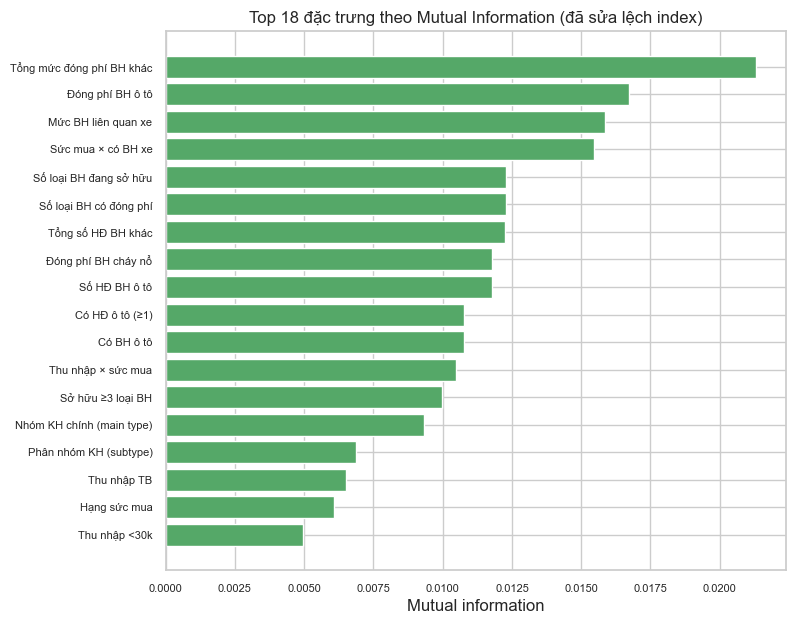

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
t = mi.head(18)[::-1]
ax.barh([disp(c) for c in t.index], t.values, color="#55a868")
ax.set_title("Top 18 đặc trưng theo Mutual Information (đã sửa lệch index)")
ax.set_xlabel("Mutual information"); ax.tick_params(labelsize=8)
savefig("MV03_mutual_info"); plt.show()

## 6. Tuning Optuna (grouped + objective mượt) — P1+P3

Objective = `hits_meanK` (trung bình hits ở K=15..25%) trên **grouped OOF** → bớt nhiễu, đỡ
đuổi theo may rủi của một ngưỡng.

In [9]:
# ===== Tuning LightGBM (grouped, objective={TUNE_OBJ}) =====
t0 = time.time()
bp_LightGBM, val_LightGBM, iter_LightGBM, study_LightGBM = tune_model(
    "LightGBM", Xtr, y, FINAL_COLS, pos_rate, n_trials=N_TRIALS["LightGBM"], n_splits=5, seed=SEED,
    groups=GROUPS, objective=TUNE_OBJ, inner_es=INNER_ES)
print(f"LightGBM: best {TUNE_OBJ} = {val_LightGBM:.2f} | n_iter approx {iter_LightGBM} | {time.time()-t0:.0f}s")

LightGBM: best hits_meanK = 179.00 | n_iter approx 3 | 51s


In [10]:
# ===== Tuning XGBoost (grouped, objective={TUNE_OBJ}) =====
t0 = time.time()
bp_XGBoost, val_XGBoost, iter_XGBoost, study_XGBoost = tune_model(
    "XGBoost", Xtr, y, FINAL_COLS, pos_rate, n_trials=N_TRIALS["XGBoost"], n_splits=5, seed=SEED,
    groups=GROUPS, objective=TUNE_OBJ, inner_es=INNER_ES)
print(f"XGBoost: best {TUNE_OBJ} = {val_XGBoost:.2f} | n_iter approx {iter_XGBoost} | {time.time()-t0:.0f}s")

XGBoost: best hits_meanK = 187.80 | n_iter approx 43 | 28s


In [11]:
# ===== Tuning CatBoost (grouped, objective={TUNE_OBJ}) =====
t0 = time.time()
bp_CatBoost, val_CatBoost, iter_CatBoost, study_CatBoost = tune_model(
    "CatBoost", Xtr, y, FINAL_COLS, pos_rate, n_trials=N_TRIALS["CatBoost"], n_splits=5, seed=SEED,
    groups=GROUPS, objective=TUNE_OBJ, inner_es=INNER_ES)
print(f"CatBoost: best {TUNE_OBJ} = {val_CatBoost:.2f} | n_iter approx {iter_CatBoost} | {time.time()-t0:.0f}s")

CatBoost: best hits_meanK = 189.00 | n_iter approx 26 | 41s


In [12]:
# Grouped OOF của 3 mô hình đã tune -> thêm vào kho OOF
tuned_specs = {}; oof_dict = dict(base_oof)
for nm, bp, mi_ in [("LightGBM", bp_LightGBM, iter_LightGBM),
                    ("XGBoost",  bp_XGBoost,  iter_XGBoost),
                    ("CatBoost", bp_CatBoost, iter_CatBoost)]:
    est = build_tuned_estimator(nm, bp, mi_, pos_rate, seed=SEED)
    spec = {"est": est, "scale": False, "te": True}
    tuned_specs[nm + "*"] = spec
    o, _ = oof_proba(spec, Xtr, y, FINAL_COLS, n_repeats=N_REPEATS, seed=SEED, groups=GROUPS)
    oof_dict[nm + "*"] = o
    s = summarize(y, o)
    print(f"{nm+'*':12s} (tuned, grouped)  AUC={s['AUC']:.4f}  hits@20%={s['hits@20%']:>3d}  lift={s['lift@20%']:.2f}")

cmp = []
for nm in ["LightGBM", "XGBoost", "CatBoost"]:
    cmp.append({"model": nm, "baseline": summarize(y, oof_dict[nm])["hits@20%"],
                "tuned": summarize(y, oof_dict[nm+"*"])["hits@20%"]})
pd.DataFrame(cmp).set_index("model")

LightGBM*    (tuned, grouped)  AUC=0.7608  hits@20%=183  lift=2.63


XGBoost*     (tuned, grouped)  AUC=0.7806  hits@20%=184  lift=2.64


CatBoost*    (tuned, grouped)  AUC=0.7744  hits@20%=187  lift=2.69


,baseline,tuned
model,,
LightGBM,168,183
XGBoost,180,184
CatBoost,183,187


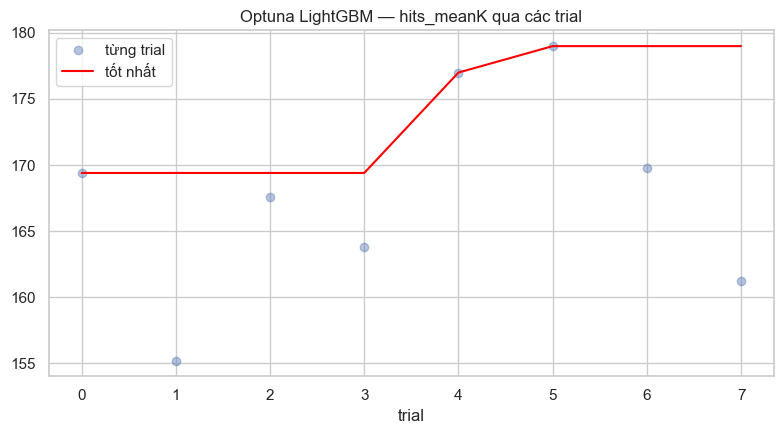

In [13]:
# Lịch sử tối ưu Optuna (LightGBM)
fig, ax = plt.subplots(figsize=(8, 4.5))
vals = [t.value for t in study_LightGBM.trials if t.value is not None]
ax.plot(vals, "o", alpha=.4, label="từng trial")
ax.plot(np.maximum.accumulate(vals), "-", color="red", label="tốt nhất")
ax.set_title(f"Optuna LightGBM — {TUNE_OBJ} qua các trial"); ax.set_xlabel("trial"); ax.legend()
plt.tight_layout(); savefig("MV04_optuna"); plt.show()

## 7. Ensemble + chọn ổn định — P1+P2

Xếp hạng kho OOF bằng `mean_hits_over_k` (tie-break AUC) thay vì hits@20% đơn lẻ. So từng mô
hình vs **rank-average** vs **stacking** (grouped). Ưu tiên rank-average trừ khi stacking
vượt rõ (> 1 std).

In [14]:
# Xếp hạng ổn định: mean_hits_over_k, tie-break AUC
rank_tbl = pd.DataFrame({
    "meanK": {k: mean_hits_over_k(y, v) for k, v in oof_dict.items()},
    "hits@20%": {k: summarize(y, v)["hits@20%"] for k, v in oof_dict.items()},
    "AUC": {k: summarize(y, v)["AUC"] for k, v in oof_dict.items()},
}).sort_values(["meanK", "AUC"], ascending=False)
print("Xếp hạng kho OOF (theo mean_hits_over_k):"); print(rank_tbl.head(8).round(3))
TOP = rank_tbl.head(3).index.tolist()
print("Ứng viên ensemble:", TOP)

ens_res, ra_oof, st_oof = compare_ensembles(oof_dict, TOP, y, groups=GROUPS)
ens_res["meanK"] = [mean_hits_over_k(y, oof_dict[n]) if n in oof_dict else
                    (mean_hits_over_k(y, ra_oof) if n.startswith("Rank-Avg") else mean_hits_over_k(y, st_oof))
                    for n in ens_res.index]
print(); print(ens_res[["AUC", "hits@20%", "meanK", "lift@20%"]].round(3))

# Ưu tiên rank-average; chỉ chọn stacking nếu vượt > 1 std của hits
hstd = float(base_res["hits@20%_std"].median())
ra_h = summarize(y, ra_oof)["hits@20%"]; st_h = summarize(y, st_oof)["hits@20%"]
FINAL = "Stacking-LR" if (st_h - ra_h) > hstd else "Rank-Avg"
print(f"\nrank-avg hits={ra_h} | stacking hits={st_h} | std~{hstd:.1f} -> Phương án cuối: {FINAL}")

Xếp hạng kho OOF (theo mean_hits_over_k):
             meanK  hits@20%    AUC
CatBoost*    188.0       187  0.774
XGBoost*     186.2       184  0.781
LightGBM*    185.2       183  0.761
CatBoost     181.2       183  0.767
LDA          181.2       183  0.749
XGBoost      177.8       180  0.760
BernoulliNB  172.8       177  0.730
LogReg       170.4       174  0.738
Ứng viên ensemble: ['CatBoost*', 'XGBoost*', 'LightGBM*']



                                           AUC  hits@20%  meanK  lift@20%
combo                                                                    
Rank-Avg (CatBoost*+XGBoost*+LightGBM*)  0.776       189  186.8     2.714
CatBoost*                                0.774       187  188.0     2.685
Stacking-LR                              0.777       185  187.8     2.657
XGBoost*                                 0.781       184  186.2     2.642
LightGBM*                                0.761       183  185.2     2.628

rank-avg hits=189 | stacking hits=185 | std~2.6 -> Phương án cuối: Rank-Avg


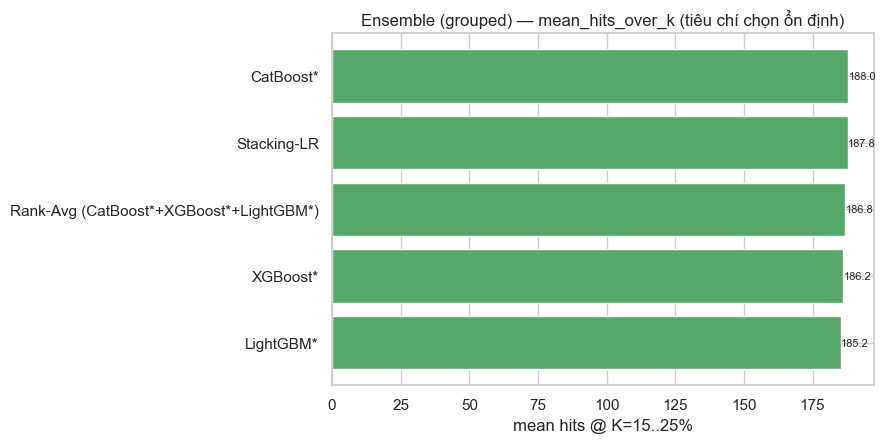

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.6))
e = ens_res.sort_values("meanK")
ax.barh(e.index, e["meanK"], color="#55a868")
ax.set_title("Ensemble (grouped) — mean_hits_over_k (tiêu chí chọn ổn định)")
ax.set_xlabel("mean hits @ K=15..25%")
for i, v in enumerate(e["meanK"]): ax.text(v+0.2, i, f"{v:.1f}", va="center", fontsize=8)
plt.tight_layout(); savefig("MV05_ensemble"); plt.show()

## 8. Mô hình cuối → `submission_800_v2.txt`

Refit trên toàn bộ train, chấm điểm test. Ghi ra file **_v2** (KHÔNG đè submission v1).

In [16]:
all_specs = {**models, **tuned_specs}
def refit_score(name):
    return score_test(fit_full(all_specs[name], Xtr, y, FINAL_COLS), Xte)

if FINAL == "Rank-Avg":
    member = {n: refit_score(n) for n in TOP}
    test_score = np.mean([to_rank(member[n]) for n in TOP], axis=0)
    print("Phương án: rank-average của", TOP)
else:
    from sklearn.linear_model import LogisticRegression
    meta = LogisticRegression(max_iter=2000, class_weight="balanced").fit(
        np.column_stack([oof_dict[n] for n in TOP]), y)
    test_score = meta.predict_proba(np.column_stack([refit_score(n) for n in TOP]))[:, 1]
    print("Phương án: stacking-LR trên", TOP)

top800, full = make_submission(test_score, test_ids, k=800,
                               out_path="submission_800_v2.txt", full_csv="outputs/test_scores_v2.csv")
ok, _ = verify_submission("submission_800_v2.txt")
print("Kiểm tra file nộp v2:", ok)
print("5 ID điểm cao nhất:", top800["ID"].head().tolist())

Phương án: rank-average của ['CatBoost*', 'XGBoost*', 'LightGBM*']
Kiểm tra file nộp v2: {'đủ k dòng': True, 'ID duy nhất': True, 'trong [1,4000]': True}
5 ID điểm cao nhất: [57, 1243, 2844, 166, 948]


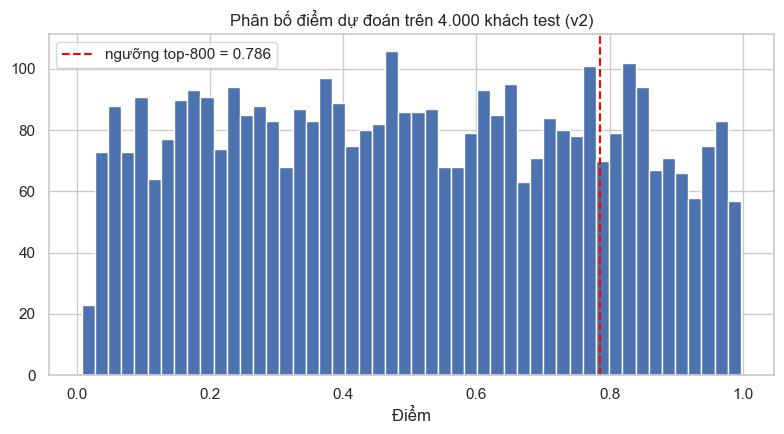

Kỳ vọng (grouped OOF): lift@20% ~ 2.71x -> trong 800 chọn có ~130 người mua (so với ~48 nếu ngẫu nhiên).


In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(full["score"], bins=50, color="#4c72b0", edgecolor="white")
thr = full.iloc[799]["score"]
ax.axvline(thr, color="red", ls="--", label=f"ngưỡng top-800 = {thr:.3f}")
ax.set_title("Phân bố điểm dự đoán trên 4.000 khách test (v2)"); ax.set_xlabel("Điểm"); ax.legend()
plt.tight_layout(); savefig("MV06_test_score_dist"); plt.show()
lift_final = float(ens_res.iloc[0]["lift@20%"])
print(f"Kỳ vọng (grouped OOF): lift@20% ~ {lift_final:.2f}x -> trong 800 chọn có ~{lift_final*pos_rate*800:.0f} người mua "
      f"(so với ~{pos_rate*800:.0f} nếu ngẫu nhiên).")

## 9. Giải thích (SHAP) — bọc an toàn

SHAP cần numpy>=2 nhưng dự án đang pin numpy<2 (để pandas/matplotlib chạy). Cell tự bỏ qua
nếu lỗi; muốn có biểu đồ: cài `shap` bản hợp numpy 1.x rồi chạy lại.

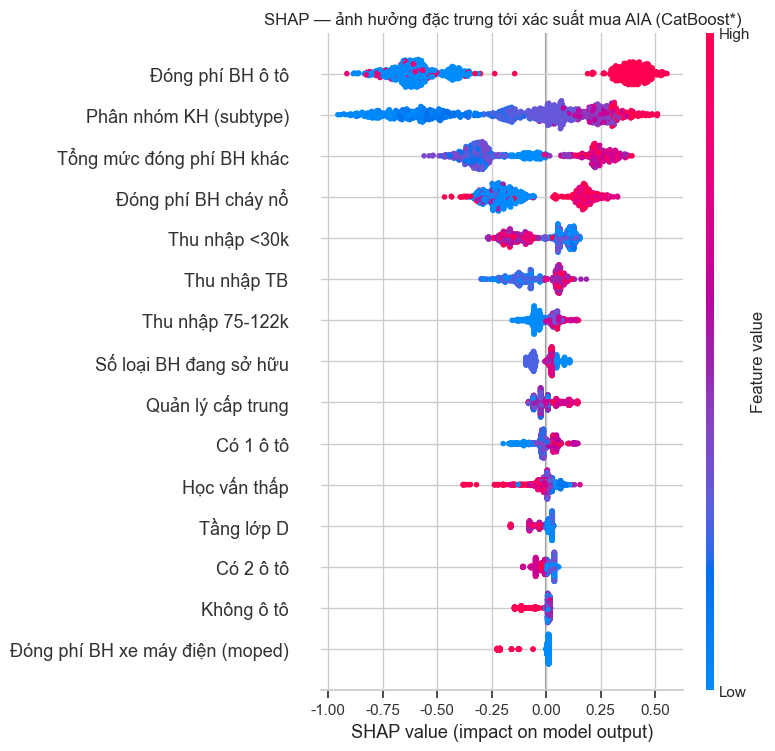

Đã vẽ SHAP cho CatBoost*


In [18]:
try:
    import shap
    expl_name = next((n for n in TOP if n.rstrip("*") in
                     ("LightGBM","XGBoost","CatBoost","RandomForest","ExtraTrees","HistGB")), None)
    if expl_name is None: raise RuntimeError("Không có mô hình cây trong TOP để giải thích.")
    pre = make_preprocessor(FINAL_COLS, scale=False).fit(Xtr, y)
    Xenc = pre.transform(Xtr); feat_names = [disp(c) for c in FINAL_COLS]
    clf = clone(all_specs[expl_name]["est"]).fit(Xenc, y)
    idx = np.random.RandomState(0).choice(len(Xtr), min(1000, len(Xtr)), replace=False)
    sv = shap.TreeExplainer(clf).shap_values(Xenc[idx])
    sv1 = sv[1] if isinstance(sv, list) else sv
    shap.summary_plot(sv1, Xenc[idx], feature_names=feat_names, show=False, max_display=15)
    plt.title(f"SHAP — ảnh hưởng đặc trưng tới xác suất mua AIA ({expl_name})")
    savefig("MV07_shap_summary"); plt.show()
    print("Đã vẽ SHAP cho", expl_name)
except Exception as e:
    print("Bỏ qua SHAP:", type(e).__name__, str(e)[:120])
    print("Để có SHAP: pip install \"shap==0.44\" (hợp numpy 1.x) rồi chạy lại cell này.")

## 10. Tổng kết & so v1 ↔ v2

In [19]:
print("="*66); print("TỔNG KẾT MODEL v2 — VPINS AIA"); print("="*66)
print(f"Đánh giá: GROUPED (trung thực) | N_REPEATS={N_REPEATS} | tuning obj={TUNE_OBJ}")
print(f"Bộ đặc trưng: {len(FINAL_COLS)} cột | Phương án cuối: {FINAL}")
fin_oof = ra_oof if FINAL == "Rank-Avg" else st_oof
s = summarize(y, fin_oof)
print(f"OOF (grouped) phương án cuối: AUC={s['AUC']:.4f} | hits@20%={s['hits@20%']}/{int(y.sum())} | "
      f"meanK={mean_hits_over_k(y, fin_oof):.1f} | lift={s['lift@20%']:.2f}x")

# So trùng ID với submission v1 (nếu có)
p1 = Path("submission_800.txt")
if p1.exists():
    s1 = set(pd.read_csv(p1, header=None)[0]); s2 = set(top800["ID"])
    inter = len(s1 & s2)
    print(f"\nSo với submission_800.txt (v1): trùng {inter}/800 ID ({inter/800*100:.0f}%); "
          f"khác {800-inter} ID.")
else:
    print("\n(Chưa có submission_800.txt v1 để so.)")
print("\nFile v2: submission_800_v2.txt | outputs/test_scores_v2.csv | figures/MV01..MV07")

TỔNG KẾT MODEL v2 — VPINS AIA
Đánh giá: GROUPED (trung thực) | N_REPEATS=3 | tuning obj=hits_meanK
Bộ đặc trưng: 98 cột | Phương án cuối: Rank-Avg
OOF (grouped) phương án cuối: AUC=0.7765 | hits@20%=189/348 | meanK=186.8 | lift=2.71x

So với submission_800.txt (v1): trùng 663/800 ID (83%); khác 137 ID.

File v2: submission_800_v2.txt | outputs/test_scores_v2.csv | figures/MV01..MV07
